<a href="https://colab.research.google.com/github/paniww/klasifikasi-tiktokshop/blob/main/klasifikasi_tiktokshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_excel('/content/drive/MyDrive/MY SKRIPSI 2026/DATASET_TIKTOKSHOP.xlsx')

In [ ]:
df.head()

,no,username,text
0,1,fluffyaa_,Day cream yg cakep tp affordable menurut aku ✨...
1,2,sffhijri,Kalau ditanya kok produknya masih itu? Ya kare...
2,3,cempaka465,"Gue tuh jarang gampang kemakan review, tapi sa..."
3,4,dokterdetektifhero,Boleh dunk Brand ni collab ama DokTif ngasi ha...
4,5,review_skincarebysin,Pake sunscreen ga takut bikin kusam kalo pake ...


In [ ]:
df.columns

Index(['no', 'username', 'text'], dtype='object')

In [ ]:
def case_folding(text):
    return str(text).lower()

In [ ]:
df['case_folding'] = df['text'].apply(case_folding)

In [ ]:
df[['text','case_folding']].head()

,text,case_folding
0,Day cream yg cakep tp affordable menurut aku ✨...,day cream yg cakep tp affordable menurut aku ✨...
1,Kalau ditanya kok produknya masih itu? Ya kare...,kalau ditanya kok produknya masih itu? ya kare...
2,"Gue tuh jarang gampang kemakan review, tapi sa...","gue tuh jarang gampang kemakan review, tapi sa..."
3,Boleh dunk Brand ni collab ama DokTif ngasi ha...,boleh dunk brand ni collab ama doktif ngasi ha...
4,Pake sunscreen ga takut bikin kusam kalo pake ...,pake sunscreen ga takut bikin kusam kalo pake ...


In [ ]:
import re

teks = "diskon 50%!!!"

hasil = re.sub(r'\d+', '', teks)

print(hasil)

diskon %!!!


In [ ]:
def cleaning(text):

    text = str(text)

    # hapus URL
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # hapus mention
    text = re.sub(r'@\w+', ' ', text)

    # hapus hashtag
    text = re.sub(r'#\w+', ' ', text)

    # hapus angka
    text = re.sub(r'\d+', ' ', text)

    # hapus tanda baca & karakter selain huruf
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [ ]:
df['cleaning'] = df['case_folding'].apply(cleaning)

In [ ]:
df[['text','case_folding','cleaning']].head()

,text,case_folding,cleaning
0,Day cream yg cakep tp affordable menurut aku ✨...,day cream yg cakep tp affordable menurut aku ✨...,day cream yg cakep tp affordable menurut aku
1,Kalau ditanya kok produknya masih itu? Ya kare...,kalau ditanya kok produknya masih itu? ya kare...,kalau ditanya kok produknya masih itu ya karen...
2,"Gue tuh jarang gampang kemakan review, tapi sa...","gue tuh jarang gampang kemakan review, tapi sa...",gue tuh jarang gampang kemakan review tapi sab...
3,Boleh dunk Brand ni collab ama DokTif ngasi ha...,boleh dunk brand ni collab ama doktif ngasi ha...,boleh dunk brand ni collab ama doktif ngasi ha...
4,Pake sunscreen ga takut bikin kusam kalo pake ...,pake sunscreen ga takut bikin kusam kalo pake ...,pake sunscreen ga takut bikin kusam kalo pake ...


In [ ]:
from collections import Counter

semua_teks = " ".join(df['cleaning'])

kata = semua_teks.split()

Counter(kata).most_common(100)

[('yang', 509),
 ('ini', 412),
 ('dan', 371),
 ('di', 361),
 ('aku', 359),
 ('banget', 193),
 ('produk', 190),
 ('yg', 186),
 ('bisa', 171),
 ('buat', 166),
 ('pake', 145),
 ('ada', 144),
 ('ya', 138),
 ('review', 135),
 ('tapi', 127),
 ('dari', 126),
 ('lagi', 125),
 ('jadi', 117),
 ('beli', 115),
 ('lebih', 113),
 ('bikin', 108),
 ('udah', 107),
 ('juga', 106),
 ('mau', 103),
 ('ga', 102),
 ('hari', 96),
 ('viral', 95),
 ('skincare', 93),
 ('pakai', 93),
 ('bagus', 92),
 ('nya', 92),
 ('untuk', 90),
 ('gak', 89),
 ('dengan', 85),
 ('kulit', 83),
 ('barang', 83),
 ('murah', 82),
 ('kalian', 80),
 ('banyak', 76),
 ('cuma', 75),
 ('atau', 72),
 ('aja', 71),
 ('sekarang', 71),
 ('tas', 70),
 ('sering', 67),
 ('bgt', 66),
 ('jujur', 66),
 ('cek', 66),
 ('tiktok', 66),
 ('sih', 65),
 ('cocok', 65),
 ('sama', 64),
 ('semua', 62),
 ('harga', 62),
 ('keranjang', 62),
 ('langsung', 62),
 ('sepatu', 61),
 ('spill', 61),
 ('karena', 59),
 ('kalau', 58),
 ('punya', 58),
 ('kuning', 58),
 ('yaa', 

In [ ]:
from collections import Counter

semua_teks = " ".join(df['cleaning'])

kata = semua_teks.split()

Counter(kata).most_common(100)

[('yang', 509),
 ('ini', 412),
 ('dan', 371),
 ('di', 361),
 ('aku', 359),
 ('banget', 193),
 ('produk', 190),
 ('yg', 186),
 ('bisa', 171),
 ('buat', 166),
 ('pake', 145),
 ('ada', 144),
 ('ya', 138),
 ('review', 135),
 ('tapi', 127),
 ('dari', 126),
 ('lagi', 125),
 ('jadi', 117),
 ('beli', 115),
 ('lebih', 113),
 ('bikin', 108),
 ('udah', 107),
 ('juga', 106),
 ('mau', 103),
 ('ga', 102),
 ('hari', 96),
 ('viral', 95),
 ('skincare', 93),
 ('pakai', 93),
 ('bagus', 92),
 ('nya', 92),
 ('untuk', 90),
 ('gak', 89),
 ('dengan', 85),
 ('kulit', 83),
 ('barang', 83),
 ('murah', 82),
 ('kalian', 80),
 ('banyak', 76),
 ('cuma', 75),
 ('atau', 72),
 ('aja', 71),
 ('sekarang', 71),
 ('tas', 70),
 ('sering', 67),
 ('bgt', 66),
 ('jujur', 66),
 ('cek', 66),
 ('tiktok', 66),
 ('sih', 65),
 ('cocok', 65),
 ('sama', 64),
 ('semua', 62),
 ('harga', 62),
 ('keranjang', 62),
 ('langsung', 62),
 ('sepatu', 61),
 ('spill', 61),
 ('karena', 59),
 ('kalau', 58),
 ('punya', 58),
 ('kuning', 58),
 ('yaa', 

In [ ]:
normalisasi_dict = {

    'yg':'yang',
    'ga':'tidak',
    'gak':'tidak',
    'nggak':'tidak',
    'g':'tidak',
    'dunk':'dong',

    'udah':'sudah',
    'aja':'saja',
    'bgt':'banget',

    'kalo':'kalau',
    'kl':'kalau',

    'sampe':'sampai',
    'ngasi':'memberi',

    'pake':'pakai',
    'kepake':'terpakai',
    'dipake':'dipakai',

    'tau':'tahu',
    'tp':'tapi',
    'tuh':'itu',

    'gue':'saya',
    'gw':'saya',

    'nih':'ini',
    'ni':'ini',
    'yaa':'ya'
}

In [ ]:
def normalisasi(text):

    hasil = []

    for kata in text.split():

        hasil.append(
            normalisasi_dict.get(kata, kata)
        )

    return " ".join(hasil)

In [ ]:
df['normalisasi'] = df['cleaning'].apply(normalisasi)

In [ ]:
df[['cleaning','normalisasi']].head()

,cleaning,normalisasi
0,day cream yg cakep tp affordable menurut aku,day cream yang cakep tapi affordable menurut aku
1,kalau ditanya kok produknya masih itu ya karen...,kalau ditanya kok produknya masih itu ya karen...
2,gue tuh jarang gampang kemakan review tapi sab...,saya itu jarang gampang kemakan review tapi sa...
3,boleh dunk brand ni collab ama doktif ngasi ha...,boleh dong brand ini collab ama doktif memberi...
4,pake sunscreen ga takut bikin kusam kalo pake ...,pakai sunscreen tidak takut bikin kusam kalau ...


In [ ]:
def tokenizing(text):
    return text.split()

In [ ]:
df['tokenizing'] = df['normalisasi'].apply(tokenizing)

In [ ]:
df[['normalisasi','tokenizing']].head(10)

,normalisasi,tokenizing
0,day cream yang cakep tapi affordable menurut aku,"[day, cream, yang, cakep, tapi, affordable, me..."
1,kalau ditanya kok produknya masih itu ya karen...,"[kalau, ditanya, kok, produknya, masih, itu, y..."
2,saya itu jarang gampang kemakan review tapi sa...,"[saya, itu, jarang, gampang, kemakan, review, ..."
3,boleh dong brand ini collab ama doktif memberi...,"[boleh, dong, brand, ini, collab, ama, doktif,..."
4,pakai sunscreen tidak takut bikin kusam kalau ...,"[pakai, sunscreen, tidak, takut, bikin, kusam,..."
5,rugi banget kalau tidak beli alat parutan bask...,"[rugi, banget, kalau, tidak, beli, alat, parut..."
6,sapu otomatis wah kalian harus punya sih bikin...,"[sapu, otomatis, wah, kalian, harus, punya, si..."
7,facial wash yang viral ini ternyata beneran ba...,"[facial, wash, yang, viral, ini, ternyata, ben..."
8,pantesan zaskia gotik pakai reviewnya jujur po...,"[pantesan, zaskia, gotik, pakai, reviewnya, ju..."
9,kulit lembut halus dan glowing meski lanjut us...,"[kulit, lembut, halus, dan, glowing, meski, la..."


In [ ]:
df.to_excel(
    "/content/drive/MyDrive/MY SKRIPSI 2026/hasil_tokenizing.xlsx",
    index=False
)

In [ ]:
df['jumlah_token'] = df['tokenizing'].apply(len)

df['jumlah_token'].describe()

,jumlah_token
count,1118.000000
mean,21.585868
std,26.837741
min,3.000000
25%,10.000000
50%,14.000000
75%,24.000000
max,501.000000


In [ ]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('indonesian'))

In [ ]:
print(len(stop_words))

757


In [ ]:
from nltk.corpus import stopwords

stop_words = set(
    stopwords.words('indonesian')
)

custom_stopwords = {

    'aku',
    'saya',
    'kalian',
    'kamu',

    'ya',
    'sih',

    'nih',
    'dong',

    'to',
    'it',
    'the',
    'my',

    'nya'
}

stop_words.update(custom_stopwords)

In [ ]:
def remove_stopwords(tokens):

    return [
        kata
        for kata in tokens
        if kata not in stop_words
    ]

In [ ]:
df['stopword'] = df['tokenizing'].apply(
    remove_stopwords
)

In [ ]:
df[['tokenizing','stopword']].head()

,tokenizing,stopword
0,"[day, cream, yang, cakep, tapi, affordable, me...","[day, cream, cakep, affordable]"
1,"[kalau, ditanya, kok, produknya, masih, itu, y...","[produknya, emng, pakenya, baguss, banget, has..."
2,"[saya, itu, jarang, gampang, kemakan, review, ...","[jarang, gampang, kemakan, review, sabun, muka..."
3,"[boleh, dong, brand, ini, collab, ama, doktif,...","[brand, collab, ama, doktif, harga, cinta, mas..."
4,"[pakai, sunscreen, tidak, takut, bikin, kusam,...","[pakai, sunscreen, takut, bikin, kusam, pakai,..."


In [ ]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.8 MB/s eta 0:00:00


In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

In [ ]:
factory = StemmerFactory()

stemmer = factory.create_stemmer()

In [ ]:
def stemming(tokens):

    hasil = []

    for kata in tokens:

        hasil.append(
            stemmer.stem(kata)
        )

    return " ".join(hasil)

In [ ]:
df['stemming'] = df['stopword'].apply(
    stemming
)

In [ ]:
df[
[
'stopword',
'stemming'
]
].head(20)

,stopword,stemming
0,"[day, cream, cakep, affordable]",day cream cakep affordable
1,"[produknya, emng, pakenya, baguss, banget, has...",produk emng pakenya baguss banget hasil gimana...
2,"[jarang, gampang, kemakan, review, sabun, muka...",jarang gampang makan review sabun muka bikin k...
3,"[brand, collab, ama, doktif, harga, cinta, mas...",brand collab ama doktif harga cinta masyarakat...
4,"[pakai, sunscreen, takut, bikin, kusam, pakai,...",pakai sunscreen takut bikin kusam pakai gloowb...
5,"[rugi, banget, beli, alat, parutan, baskom, pe...",rugi banget beli alat parut baskom potong sayu...
6,"[sapu, otomatis, bikin, satset, pakai, pengki,...",sapu otomatis bikin satset pakai pengki deh pr...
7,"[facial, wash, viral, beneran, bagus, gentle, ...",facial wash viral beneran bagus gentle banget ...
8,"[pantesan, zaskia, gotik, pakai, reviewnya, ju...",pantesan zaskia gotik pakai reviewnya jujur po...
9,"[kulit, lembut, halus, glowing, usia, emang, c...",kulit lembut halus glowing usia emang coba pak...


In [ ]:
kata_penting = [

    'skincare',
    'review',
    'viral',
    'voucher',
    'checkout',
    'keranjang',
    'link',
    'promo',
    'diskon',
    'murah'
]

for kata in kata_penting:

    print(
        kata,
        "->",
        stemmer.stem(kata)
    )

skincare -> skincare
review -> review
viral -> viral
voucher -> voucher
checkout -> checkout
keranjang -> keranjang
link -> link
promo -> promo
diskon -> diskon
murah -> murah


In [ ]:
output_path = "/content/drive/MyDrive/MY SKRIPSI 2026/HASIL_PREPROCESSING.xlsx"

df.to_excel(
    output_path,
    index=False
)

print("Preprocessing selesai")

Preprocessing selesai


In [ ]:
import pandas as pd

path = "/content/drive/MyDrive/MY SKRIPSI 2026/HASIL_PREPROCESSING.xlsx"

df = pd.read_excel(path)

In [ ]:
jumlah_1 = (df['labelling '] == 1).sum()
jumlah_0 = (df['labelling '] == 0).sum()
total = len(df)

print(f"Buzzer (1)     : {jumlah_1} ({jumlah_1/total*100:.2f}%)")
print(f"Non-Buzzer (0) : {jumlah_0} ({jumlah_0/total*100:.2f}%)")
print(f"Total Data     : {total}")

Buzzer (1)     : 637 (56.98%)
Non-Buzzer (0) : 481 (43.02%)
Total Data     : 1118


<Axes: xlabel='labelling '>

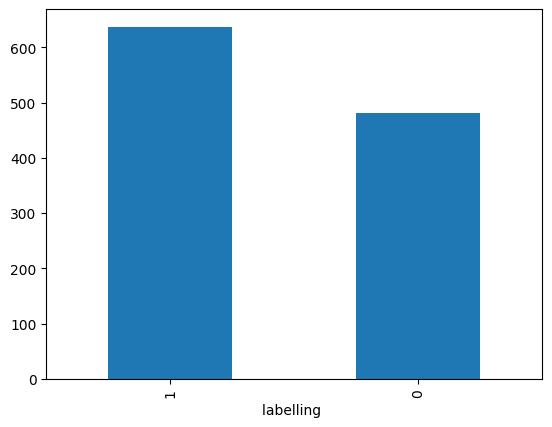

In [ ]:
df['labelling '].value_counts().plot(kind='bar')

In [ ]:
df.columns

Index(['no', 'username', 'text', 'case_folding', 'cleaning', 'normalisasi',
       'tokenizing', 'jumlah_token', 'stopword', 'stemming', 'labelling '],
      dtype='object')

In [ ]:
df['labelling '].value_counts()

,count
labelling,
1,637
0,481


In [ ]:
df[['stemming','labelling ']].isnull().sum()

,0
stemming,0
labelling,0


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

X_text = df['stemming']

y = df['labelling ']

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(X_text)

In [ ]:
print("Jumlah dokumen :", X.shape[0])
print("Jumlah fitur   :", X.shape[1])

Jumlah dokumen : 1118
Jumlah fitur   : 3887


In [ ]:
fitur = tfidf.get_feature_names_out()

print(fitur[:])

['aaaa' 'aaaaa' 'aaam' ... 'zonks' 'zus' 'zuzur']


In [ ]:
import pandas as pd

tfidf_df = pd.DataFrame(
    X.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df.to_excel(
    "/content/drive/MyDrive/MY SKRIPSI 2026/HASIL_TFIDF.xlsx",
    index=False
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,
    random_state=42,

    stratify=y
)

In [ ]:
print("Training :", X_train.shape[0])
print("Testing  :", X_test.shape[0])

Training : 894
Testing  : 224


In [ ]:
print(y_train.value_counts())

print(y_test.value_counts())

labelling 
1    509
0    385
Name: count, dtype: int64
labelling 
1    128
0     96
Name: count, dtype: int64


In [ ]:
from sklearn.naive_bayes import MultinomialNB

In [ ]:
model = MultinomialNB()

In [ ]:
model.fit(
    X_train,
    y_train
)

MultinomialNB()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
hasil_prediksi = pd.DataFrame({

    'Aktual' : y_test.values,
    'Prediksi' : y_pred
})

hasil_prediksi.head()

,Aktual,Prediksi
0,0,0
1,0,1
2,1,1
3,1,0
4,0,1


In [ ]:
import joblib

In [ ]:
model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
joblib.dump(
    model,
    "/content/drive/MyDrive/MY SKRIPSI 2026/model_naive_bayes.pkl"
)

['/content/drive/MyDrive/MY SKRIPSI 2026/model_naive_bayes.pkl']

In [ ]:
joblib.dump(
    tfidf,
    "/content/drive/MyDrive/MY SKRIPSI 2026/model_tfidf.pkl"
)

['/content/drive/MyDrive/MY SKRIPSI 2026/model_tfidf.pkl']

In [ ]:
import os

os.path.exists(
    "/content/drive/MyDrive/MY SKRIPSI 2026/model_naive_bayes.pkl"
)

True

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy :", accuracy)

Accuracy : 0.7723214285714286


In [ ]:
from sklearn.metrics import precision_score

precision = precision_score(
    y_test,
    y_pred
)

print("Precision :", precision)

Precision : 0.7692307692307693


In [ ]:
from sklearn.metrics import recall_score

recall = recall_score(
    y_test,
    y_pred
)

print("Recall :", recall)

Recall : 0.859375


In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(
    y_test,
    y_pred
)

print("F1 Score :", f1)

F1 Score : 0.8118081180811808


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.78      0.66      0.71        96
           1       0.77      0.86      0.81       128

    accuracy                           0.77       224
   macro avg       0.77      0.76      0.76       224
weighted avg       0.77      0.77      0.77       224



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[ 63  33]
 [ 18 110]]


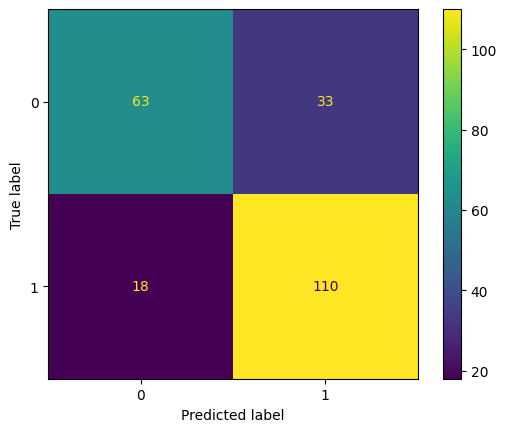

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

In [ ]:
hasil_evaluasi = pd.DataFrame({

    'Accuracy':[accuracy],
    'Precision':[precision],
    'Recall':[recall],
    'F1-Score':[f1]

})

hasil_evaluasi.to_excel(

    "/content/drive/MyDrive/MY SKRIPSI 2026/HASIL_EVALUASI.xlsx",

    index=False
)

In [ ]:
data_buzzer = df[
    df['labelling '] == 1
]

In [ ]:
from collections import Counter

semua_kata = " ".join(
    data_buzzer['stemming']
).split()

kata_buzzer = Counter(
    semua_kata
).most_common(50)

kata_buzzer

[('banget', 143),
 ('pakai', 134),
 ('bikin', 79),
 ('beli', 79),
 ('produk', 77),
 ('murah', 73),
 ('viral', 69),
 ('keranjang', 66),
 ('kuning', 63),
 ('harga', 62),
 ('bagus', 61),
 ('cek', 55),
 ('sepatu', 50),
 ('nyaman', 49),
 ('langsung', 47),
 ('promo', 45),
 ('tas', 43),
 ('link', 40),
 ('skincare', 36),
 ('hari', 36),
 ('bahan', 35),
 ('kulit', 34),
 ('rumah', 34),
 ('habis', 33),
 ('cocok', 33),
 ('yuk', 31),
 ('kualitas', 31),
 ('buru', 31),
 ('balas', 31),
 ('live', 29),
 ('bio', 28),
 ('lokal', 28),
 ('tiktok', 27),
 ('no', 26),
 ('up', 26),
 ('pilih', 26),
 ('checkout', 26),
 ('warna', 25),
 ('ribu', 25),
 ('baju', 25),
 ('beneran', 24),
 ('anti', 24),
 ('order', 24),
 ('mudah', 23),
 ('wajib', 23),
 ('klik', 23),
 ('diskon', 23),
 ('suka', 22),
 ('anak', 22),
 ('wanita', 22)]

In [ ]:
df_kata_buzzer = pd.DataFrame(

    kata_buzzer,

    columns=[
        'Kata',
        'Frekuensi'
    ]
)

df_kata_buzzer.to_excel(

    "/content/drive/MyDrive/MY SKRIPSI 2026/KATA_BUZZER.xlsx",

    index=False
)

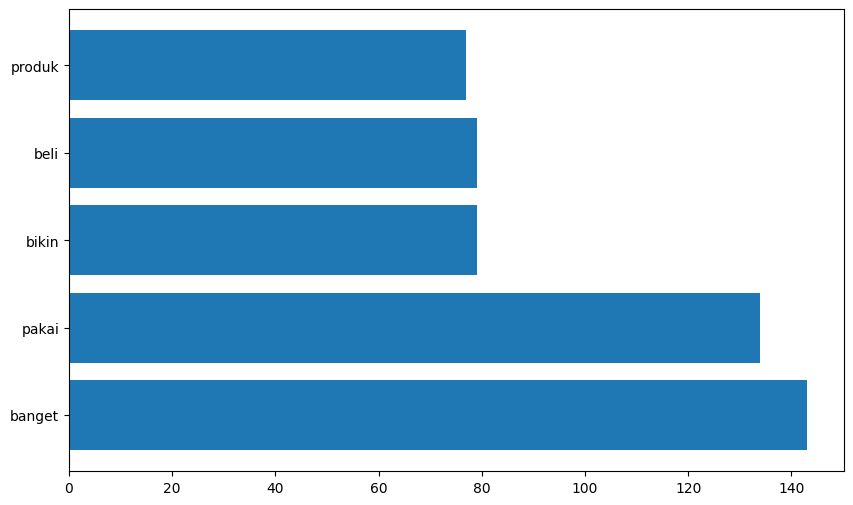

In [ ]:
top = df_kata_buzzer.head()

plt.figure(figsize=(10,6))

plt.barh(
    top['Kata'],
    top['Frekuensi']
)

plt.show()

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 70.1 MB/s eta 0:00:00


In [ ]:
%%writefile app.py

import streamlit as st
import joblib

model = joblib.load(
    "model_naive_bayes.pkl"
)

tfidf = joblib.load(
    "model_tfidf.pkl"
)

st.title(
    "Klasifikasi Akun Buzzer TikTok Shop"
)

teks = st.text_area(
    "Masukkan Caption"
)

if st.button(
    "Klasifikasi"
):

    data = tfidf.transform(
        [teks]
    )

    hasil = model.predict(
        data
    )

    if hasil[0] == 1:
        st.error(
            "Buzzer"
        )
    else:
        st.success(
            "Non-Buzzer"
        )

Writing app.py


In [ ]:
!streamlit run app.py



2026-06-04 11:53:44.122 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.138.105.142:8501

  Stopping...


In [ ]:
import joblib

model = joblib.load(
    "/content/drive/MyDrive/MY SKRIPSI 2026/model_naive_bayes.pkl"
)

tfidf = joblib.load(
    "/content/drive/MyDrive/MY SKRIPSI 2026/model_tfidf.pkl"
)

teks = input("Masukkan Caption: ")

data = tfidf.transform([teks])

hasil = model.predict(data)

if hasil[0] == 1:
    print("Hasil Klasifikasi : BUZZER")
else:
    print("Hasil Klasifikasi : NON-BUZZER")

Masukkan Caption: produk emng pakenya baguss banget hasil gimana donggg jd ken banget kasih orang produk emng bagus walopun kaya banyk kasih jg wkwk dapet compliment dr org suami jyakhh kulit glowing is another level of happiness masya allah tabarakallah
Hasil Klasifikasi : NON-BUZZER


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall   :", recall_score(y_test,y_pred))
print("F1 Score :", f1_score(y_test,y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test,y_pred))

Accuracy : 0.7723214285714286
Precision: 0.7692307692307693
Recall   : 0.859375
F1 Score : 0.8118081180811808

Confusion Matrix
[[ 63  33]
 [ 18 110]]


In [ ]:
import pandas as pd

kamus_normalisasi = {
    'yg':'yang',
    'ga':'tidak',
    'gak':'tidak',
    'nggak':'tidak',
    'g':'tidak',
    'dunk':'dong',
    'udah':'sudah',
    'aja':'saja',
    'bgt':'banget',
    'kalo':'kalau',
    'kl':'kalau',
    'sampe':'sampai',
    'ngasi':'memberi',
    'pake':'pakai',
    'kepake':'terpakai',
    'dipake':'dipakai',
    'tau':'tahu',
    'tp':'tapi',
    'tuh':'itu',
    'gue':'saya',
    'gw':'saya',
    'nih':'ini',
    'ni':'ini',
    'yaa':'ya'
}

tabel_normalisasi = pd.DataFrame(
    kamus_normalisasi.items(),
    columns=[
        "Kata Tidak Baku",
        "Kata Baku"
    ]
)

tabel_normalisasi

,Kata Tidak Baku,Kata Baku
0,yg,yang
1,ga,tidak
2,gak,tidak
3,nggak,tidak
4,g,tidak
5,dunk,dong
6,udah,sudah
7,aja,saja
8,bgt,banget
9,kalo,kalau


In [ ]:
tabel_normalisasi.to_excel(
    "/content/drive/MyDrive/MY SKRIPSI 2026/KAMUS_NORMALISASI.xlsx",
    index=False
)

print("Kamus normalisasi berhasil disimpan")

Kamus normalisasi berhasil disimpan


In [ ]:
!pip install streamlit joblib scikit-learn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 46.6 MB/s eta 0:00:00


In [ ]:
import os

os.listdir("/content/drive/MyDrive/MY SKRIPSI 2026")

['DATASET_TIKTOKSHOP.xlsx',
 'DATASET_LABELLING.xlsx',
 'DATASET_MENTAH.xlsx',
 'MY SKRIPSI.docx',
 'hasil_tokenizing.xlsx',
 'frekuensi_stemming_filter.xlsx',
 'HASIL_PREPROCESSING.xlsx',
 'HASIL_TFIDF.xlsx',
 'model_naive_bayes.pkl',
 'model_tfidf.pkl',
 'HASIL_EVALUASI.xlsx',
 'KATA_BUZZER.xlsx',
 'KAMUS_NORMALISASI.xlsx']

In [ ]:
import joblib

model = joblib.load(
    "/content/drive/MyDrive/MY SKRIPSI 2026/model_naive_bayes.pkl"
)

tfidf = joblib.load(
    "/content/drive/MyDrive/MY SKRIPSI 2026/model_tfidf.pkl"
)

In [ ]:
teks = "buruan checkout sekarang sebelum kehabisan promo"

data = tfidf.transform([teks])

hasil = model.predict(data)

print(hasil)

[1]


In [ ]:
teks = "buruan checkout sekarang sebelum kehabisan promo"

data = tfidf.transform([teks])

hasil = model.predict(data)[0]

if hasil == 1:
    print("BUZZER")
else:
    print("NON-BUZZER")

BUZZER


In [ ]:
%%writefile app.py

import streamlit as st
import joblib

model = joblib.load("model_naive_bayes.pkl")
tfidf = joblib.load("model_tfidf.pkl")

st.title("Klasifikasi Caption TikTok Shop")

caption = st.text_area("Masukkan Caption", height=200)

if st.button("Analisis"):

    data = tfidf.transform([caption])

    hasil = model.predict(data)[0]

    if hasil == 1:
        st.success("BUZZER")
    else:
        st.success("NON-BUZZER")

Writing app.py


In [ ]:
import os
print(os.listdir())

['.config', 'drive', 'app.py', 'sample_data']


In [ ]:
%%writefile requirements.txt

streamlit
scikit-learn
joblib
numpy
pandas

Writing requirements.txt


In [ ]:
import os
print(os.listdir())

['.config', 'requirements.txt', 'drive', 'app.py', 'sample_data']


In [ ]:
!cp "/content/drive/MyDrive/MY SKRIPSI 2026/model_naive_bayes.pkl" .
!cp "/content/drive/MyDrive/MY SKRIPSI 2026/model_tfidf.pkl" .

In [ ]:
import os
print(os.listdir())

['.config', 'requirements.txt', 'drive', 'model_tfidf.pkl', 'model_naive_bayes.pkl', 'app.py', 'sample_data']


In [ ]:
print(os.listdir())

['.config', 'requirements.txt', 'drive', 'model_tfidf.pkl', 'model_naive_bayes.pkl', 'app.py', 'sample_data']


In [ ]:
with open("app.py", "r") as f:
    print(f.read())


import streamlit as st
import joblib

model = joblib.load("model_naive_bayes.pkl")
tfidf = joblib.load("model_tfidf.pkl")

st.title("Klasifikasi Caption TikTok Shop")

caption = st.text_area("Masukkan Caption", height=200)

if st.button("Analisis"):

    data = tfidf.transform([caption])

    hasil = model.predict(data)[0]

    if hasil == 1:
        st.success("BUZZER")
    else:
        st.success("NON-BUZZER")



In [ ]:
!cp app.py "/content/drive/MyDrive/MY SKRIPSI 2026/"
!cp requirements.txt "/content/drive/MyDrive/MY SKRIPSI 2026/"

In [ ]:
import os

os.listdir("/content/drive/MyDrive/MY SKRIPSI 2026")

['DATASET_TIKTOKSHOP.xlsx',
 'DATASET_LABELLING.xlsx',
 'DATASET_MENTAH.xlsx',
 'MY SKRIPSI.docx',
 'hasil_tokenizing.xlsx',
 'frekuensi_stemming_filter.xlsx',
 'HASIL_PREPROCESSING.xlsx',
 'HASIL_TFIDF.xlsx',
 'model_naive_bayes.pkl',
 'model_tfidf.pkl',
 'HASIL_EVALUASI.xlsx',
 'KATA_BUZZER.xlsx',
 'KAMUS_NORMALISASI.xlsx',
 'app.py',
 'requirements.txt']

In [ ]:
import os

for file in os.listdir():
    print(file)

.config
drive
sample_data


In [ ]:
import os

print(os.listdir())

['.config', 'drive', 'sample_data']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

print(os.listdir('/content/drive/MyDrive'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['Colab Notebooks', 'MY SKRIPSI 2026', 'Untitled spreadsheet.gsheet', 'MY SKRIPSI CINTAA', 'REVIEW JURNAL DI ERA DIGITAL INI APA TANTANGAN DAN JUGA KEMUDAHAN DALAM ASPEK TECHNOPRENEURR.pdf']


In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith('.xlsx'):
            print(os.path.join(root, file))

/content/drive/MyDrive/MY SKRIPSI 2026/HASIL_TFIDF.xlsx
/content/drive/MyDrive/MY SKRIPSI 2026/DATASET_TIKTOKSHOP.xlsx
/content/drive/MyDrive/MY SKRIPSI 2026/DATASET_LABELLING.xlsx
/content/drive/MyDrive/MY SKRIPSI 2026/DATASET_MENTAH.xlsx
/content/drive/MyDrive/MY SKRIPSI 2026/hasil_tokenizing.xlsx
/content/drive/MyDrive/MY SKRIPSI 2026/frekuensi_stemming_filter.xlsx
/content/drive/MyDrive/MY SKRIPSI 2026/HASIL_PREPROCESSING.xlsx
/content/drive/MyDrive/MY SKRIPSI 2026/HASIL_EVALUASI.xlsx
/content/drive/MyDrive/MY SKRIPSI 2026/KATA_BUZZER.xlsx
/content/drive/MyDrive/MY SKRIPSI 2026/KAMUS_NORMALISASI.xlsx
/content/drive/MyDrive/MY SKRIPSI CINTAA/DATA_SELEKSI.xlsx
/content/drive/MyDrive/MY SKRIPSI CINTAA/DATASET_ALL.xlsx
/content/drive/MyDrive/MY SKRIPSI CINTAA/DATASET_LABELLING.xlsx
/content/drive/MyDrive/MY SKRIPSI CINTAA/PRE_CASE_FOLDING.xlsx
/content/drive/MyDrive/MY SKRIPSI CINTAA/PRE_CLEANING.xlsx
/content/drive/MyDrive/MY SKRIPSI CINTAA/PRE_NORMALISASI.xlsx
/content/drive/MyDrive/

In [ ]:
import pandas as pd

df = pd.read_excel(
    "/content/drive/MyDrive/MY SKRIPSI 2026/DATASET_LABELLING.xlsx"
)

print(df.columns)
df.head()

Index(['no', 'username', 'text', 'labelling '], dtype='object')


,no,username,text,labelling
0,1,fluffyaa_,Day cream yg cakep tp affordable menurut aku ✨...,1
1,2,sffhijri,Kalau ditanya kok produknya masih itu? Ya kare...,0
2,3,cempaka465,"Gue tuh jarang gampang kemakan review, tapi sa...",0
3,4,dokterdetektifhero,Boleh dunk Brand ni collab ama DokTif ngasi ha...,0
4,5,review_skincarebysin,Pake sunscreen ga takut bikin kusam kalo pake ...,1


In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".pkl"):
            print(os.path.join(root, file))

/content/drive/MyDrive/MY SKRIPSI 2026/model_naive_bayes.pkl
/content/drive/MyDrive/MY SKRIPSI 2026/model_tfidf.pkl
/content/drive/MyDrive/MY SKRIPSI CINTAA/model_naive_bayes.pkl
/content/drive/MyDrive/MY SKRIPSI CINTAA/tfidf_vectorizer.pkl


In [ ]:
model = joblib.load(
    "/content/drive/MyDrive/MY SKRIPSI 2026/model_naive_bayes.pkl"
)

tfidf = joblib.load(
    "/content/drive/MyDrive/MY SKRIPSI 2026/model_tfidf.pkl"
)

In [ ]:
import pandas as pd

kata_buzzer = pd.read_excel(
    "/content/drive/MyDrive/MY SKRIPSI 2026/KATA_BUZZER.xlsx"
)

print(kata_buzzer.head(20))

         Kata  Frekuensi
0      banget        143
1       pakai        134
2       bikin         79
3        beli         79
4      produk         77
5       murah         73
6       viral         69
7   keranjang         66
8      kuning         63
9       harga         62
10      bagus         61
11        cek         55
12     sepatu         50
13     nyaman         49
14   langsung         47
15      promo         45
16        tas         43
17       link         40
18   skincare         36
19       hari         36


In [ ]:
import pandas as pd

df = pd.read_excel(
    "/content/drive/MyDrive/MY SKRIPSI 2026/DATASET_LABELLING.xlsx"
)

df['labelling '].value_counts()

,count
labelling,
1,637
0,481


In [ ]:
import pandas as pd
from collections import Counter

df = pd.read_excel(
    "/content/drive/MyDrive/MY SKRIPSI 2026/DATASET_LABELLING.xlsx"
)

# Ambil caption non-buzzer
non_buzzer = df[df['labelling '] == 0]

# Gabungkan seluruh teks
teks = " ".join(non_buzzer['text'].astype(str))

# Hitung frekuensi kata
counter = Counter(teks.lower().split())

# Ambil 20 kata teratas
kata_non = pd.DataFrame(
    counter.most_common(20),
    columns=['Kata', 'Frekuensi']
)

# Simpan
kata_non.to_excel(
    "/content/drive/MyDrive/MY SKRIPSI 2026/KATA_NON_BUZZER.xlsx",
    index=False
)

kata_non

,Kata,Frekuensi
0,aku,255
1,yang,253
2,ini,197
3,dan,170
4,di,160
5,yg,131
6,review,110
7,produk,107
8,#fyp,99
9,pake,93


In [ ]:
df_pre = pd.read_excel(
    "/content/drive/MyDrive/MY SKRIPSI 2026/HASIL_PREPROCESSING.xlsx"
)

print(df_pre.columns)

Index(['no', 'username', 'text', 'case_folding', 'cleaning', 'normalisasi',
       'tokenizing', 'jumlah_token', 'stopword', 'stemming', 'labelling '],
      dtype='object')


In [ ]:
import pandas as pd
from collections import Counter

# Load hasil preprocessing
df = pd.read_excel(
    "/content/drive/MyDrive/MY SKRIPSI 2026/HASIL_PREPROCESSING.xlsx"
)

# Ambil data non-buzzer
df_non = df[df['labelling '] == 0]

# Gabungkan seluruh hasil stemming
teks_non = " ".join(df_non['stemming'].astype(str))

# Hitung frekuensi kata
counter_non = Counter(teks_non.split())

# Ambil 20 kata teratas
kata_non = pd.DataFrame(
    counter_non.most_common(20),
    columns=['Kata', 'Frekuensi']
)

# Simpan ke Excel
kata_non.to_excel(
    "/content/drive/MyDrive/MY SKRIPSI 2026/KATA_NONBUZZER.xlsx",
    index=False
)

print(kata_non)

        Kata  Frekuensi
0      pakai        272
1     produk        138
2     review        119
3     banget        118
4      jujur         67
5     barang         63
6      kulit         60
7   skincare         57
8       beli         54
9      bagus         50
10     spill         42
11    tiktok         39
12      coba         34
13      hari         34
14     cocok         33
15     harga         32
16       tas         32
17     hasil         31
18     bikin         29
19     brand         28


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

/bin/bash: line 1: streamlit: command not found
⠙⠹⠸⠼⠴⠦Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 